<div style="
    background-color: #f2f2f2;
    padding: 15px;
    text-align: center;
">
    <h1 style="
        margin: 0;
        font-family: Arial, sans-serif;
        color: #333;
    ">
       IMAGE SEGMENTATION
    </h1>
</div>


# image Preprocessing

### Import Libraries

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.utils import resample


### loading image

(np.float64(-0.5), np.float64(735.5), np.float64(735.5), np.float64(-0.5))

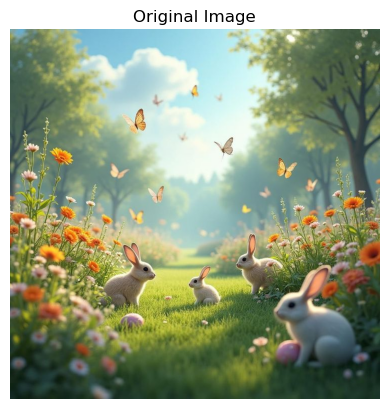

In [5]:
# path to your image
image = cv2.imread(r"C:\Users\RASHID\Downloads\download (1).jpg")      
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")


In [ ]:
# Convert image to pixel data
S
pixels = image.reshape((-1, 3))
pixels = np.float32(pixels)


# Image Segmentation

##### Selection of Optimal K for Image Segmentation Using K-Means Clustering

In [ ]:
# Applying K-means in Image segmentation

wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pixels)
    wcss.append(kmeans.inertia_)


##### Using Elbow Method for find number of segments

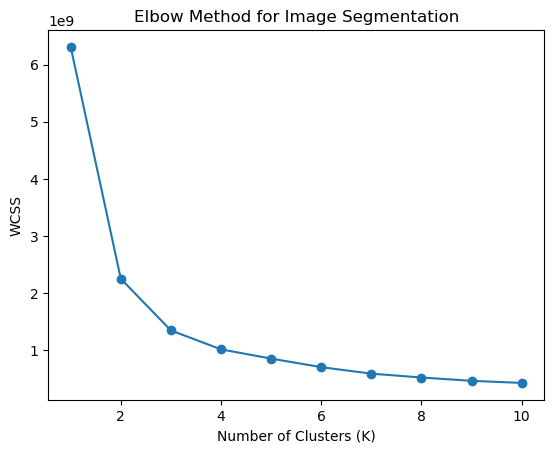

In [11]:
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Image Segmentation")
plt.show()


##### using calinski_harabasz_score for find and confirm better k 

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score

for k in range(2, 8):
    labels = KMeans(k, random_state=42, n_init=10).fit_predict(pixels)
    ch = calinski_harabasz_score(pixels, labels)
    print(f"K={k}, CH Score={ch:.2f}")


K=2, CH Score=975016.00
K=3, CH Score=994288.44
K=4, CH Score=937658.81
K=5, CH Score=860937.62
K=6, CH Score=857863.00
K=7, CH Score=868288.81


##### image segmented

(np.float64(-0.5), np.float64(735.5), np.float64(735.5), np.float64(-0.5))

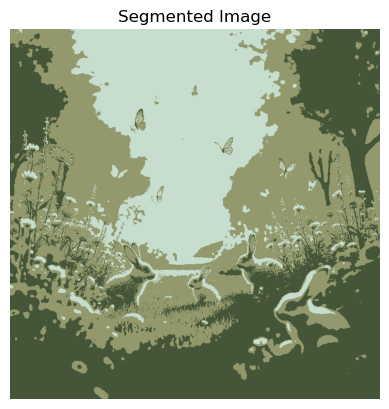

In [18]:
k=3
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(pixels)

segmented = kmeans.cluster_centers_[labels]
segmented_image = segmented.reshape(image.shape).astype(np.uint8)

plt.imshow(segmented_image)
plt.title("Segmented Image")
plt.axis("off")

# Assigning Custom Colors to segmented image regions

In [19]:
# define target colors: yellow, pink, red
target_colors = np.array([
    [255, 255,   0],   # yellow
    [255, 105, 180],   # pink
    [255,   0,   0]    # red
], dtype=np.uint8)


(np.float64(-0.5), np.float64(735.5), np.float64(735.5), np.float64(-0.5))

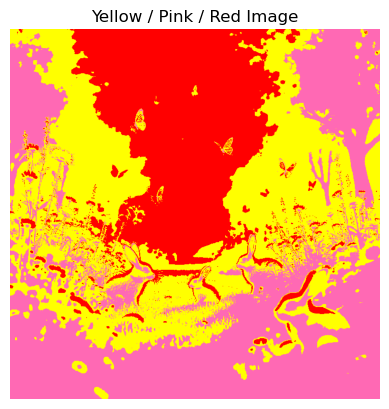

In [20]:
# assign each cluster a fixed color
segmented_fixed = target_colors[labels]

# reshape back to image
segmented_fixed_image = segmented_fixed.reshape(image.shape)

plt.imshow(segmented_fixed_image)
plt.title("Yellow / Pink / Red Image")
plt.axis("off")


#  Segmentation Output

The given segmented image divides the original image into three regions based on color similarity using K-Means clustering.
Each color represents a group of pixels with similar intensity and texture
* Red region: Dark, dense, high-intensity areas mainly forming the dominant foreground.
* Yellow region: Bright, high-contrast areas highlighting edges and textures.
* Pink region: Smooth, uniform areas representing the background with low detail.
> The result clearly shows how color-based segmentation simplifies the image by highlighting dominant regions.